# Re-evaluating the literature compounds (paper Sect. 3.9) with BIMOG + MCM training

Malonic acid was the one failure in the literature-compound check (ln γ_org MAE 0.61). The revised
manuscript says that training on the combined BIMOG + MCM pool "is expected" to fix it. This notebook tests
that claim.

**Membership check (done before training).** Malonic acid is in neither BIMOG nor MCM, so it stays a true
out-of-pool compound for every model below. 2-Propanol *is* in BIMOG (spelled "isopropranol") and falls in
the hash-split **training** set, so the draft's statement that the surrogate "never saw" it is wrong. The
other four compounds are BIMOG training molecules, and three of them also occur in MCM.

| Model | Training molecules |
|---|---|
| M1 | BIMOG train (312), the paper's setting |
| M2 | BIMOG train + MCM train (3167), the best learning-curve setting |
| M3 | all BIMOG + all MCM (3705), a release-model setting |
| M4 | M2 without the MCM species carrying ≥ 2 COOH groups (control: is the gain due to similar diacids?) |

All models use the descriptor MLP (feature set B over the union main-group vocabulary), 20 w × 4 T labels per
molecule, and seeds 0–2. Evaluation is at 19 water mass fractions in [0.05, 0.95] at 298.15 K, as in
Table 6. The paper's Table 6 used a separate dense-grid (200-point) checkpoint, so M1 is the like-for-like
reference for M2–M4.

In [1]:
import json, time, hashlib
import numpy as np, pandas as pd, torch, torch.nn as nn
import matplotlib; import matplotlib.pyplot as plt
from rdkit import Chem, RDLogger
from aiomfac_py import ActivityModel, Component
from aiomfac_py.s2as import smiles_to_components
from aiomfac_py.params import load_subgroup_params
import aiomfac_py.s2as._mapping as _m
_m.print = lambda *a, **k: None; RDLogger.DisableLog("rdApp.*")
sg = load_subgroup_params(); WATER = Component(1, "Water", ((16, 1),)); SEEDS = (0, 1, 2)

def featurize(name, smi, cat):
    r = smiles_to_components([smi], water_as_component1=True)
    if r.removed: return None
    try:
        if not (ActivityModel(r.components).evaluate([0.9, 0.1], 298.15, basis="mass").gamma_neutral > 0).all(): return None
    except Exception: return None
    mol = Chem.MolFromSmiles(smi); mh = Chem.AddHs(mol); sym = [a.GetSymbol() for a in mh.GetAtoms()]; nc = max(sym.count("C"), 1)
    return {"name": name, "smiles": smi, "canon": Chem.MolToSmiles(mol), "cat": cat, "subgroups": r.components[1].subgroups,
            "M": sum(a.GetMass() for a in mh.GetAtoms()), "oc": sym.count("O") / nc, "nc": sym.count("N") / nc,
            "n_unmatched": int(r.n_unmatched_atoms[0])}

is_test = lambda s: int(hashlib.sha256(s.encode()).hexdigest(), 16) % 100 < 15
bimog = [o for d in json.load(open("bimog_unified.json")) if (o := featurize(d["name"], d["smiles"], "bimog"))]
bcanon = {o["canon"] for o in bimog}
mraw = pd.read_csv("mcm_v331_species.tsv", sep="\t", comment="*"); mcm = []
for _, r in mraw.iterrows():
    mol = Chem.MolFromSmiles(str(r.Smiles))
    if (mol is None or str(r.Excited).lower() == "true" or any(a.GetNumRadicalElectrons() for a in mol.GetAtoms())
            or not {a.GetSymbol() for a in mol.GetAtoms()} <= {"C", "H", "O", "N"} or mol.GetNumHeavyAtoms() < 2
            or "C" not in {a.GetSymbol() for a in mol.GetAtoms()}): continue
    o = featurize(r.Name, str(r.Smiles), "mcm")
    if o and o["n_unmatched"] == 0 and o["canon"] not in bcanon: mcm.append(o)
pool = bimog + mcm
src = np.array([o["cat"] for o in pool]); test = np.array([is_test(o["smiles"]) for o in pool])
cooh = Chem.MolFromSmarts("C(=O)[OH]")
diacid = np.array([o["cat"] == "mcm" and len(Chem.MolFromSmiles(o["smiles"]).GetSubstructMatches(cooh)) >= 2 for o in pool])
print(f"BIMOG {len(bimog)}, MCM {len(mcm)}, MCM diacids {diacid.sum()}:",
      ", ".join(f"{pool[i]['name']} ({pool[i]['canon']})" for i in np.where(diacid)[0]))

TARGETS = {"Glycerol": "OCC(O)CO", "1,2,4-Butanetriol": "OCCC(O)CO", "2,5-Hexanediol": "CC(O)CCC(C)O",
           "Ethanol": "CCO", "2-Propanol": "CC(C)O", "Malonic acid": "OC(=O)CC(=O)O"}
canon_idx = {}
for i, o in enumerate(pool):
    canon_idx.setdefault(o["canon"], []).append(i)
mem = []
for nm, s in TARGETS.items():
    c = Chem.MolToSmiles(Chem.MolFromSmiles(s)); ids = canon_idx.get(c, [])
    mem.append({"compound": nm, "in BIMOG": any(src[i] == "bimog" for i in ids),
                "BIMOG split": ", ".join("held-out" if test[i] else "train" for i in ids if src[i] == "bimog") or "–",
                "in MCM (after de-dup)": any(src[i] == "mcm" for i in ids)})
display(pd.DataFrame(mem))

BIMOG 368, MCM 3337, MCM diacids 18: C1211CO2H (CC1(C)CC(C(=O)CCC(=O)O)C1CCC(=O)O), C137CO2H (C=C(CCC(=O)O)C1CC(C)(C)C1CCC(=O)O), CATECOOA (O=C(O)/C=C/C=C/C(O)=[O+][O-]), ECATECOOA (CCC(=C/C=C/C(=O)O)C(O)=[O+][O-]), IPCATECOOA (CC(C)C(=C/C=C/C(=O)O)C(O)=[O+][O-]), KLIMONIC (CC(=O)C(CCC(=O)O)CC(=O)O), LIMONIC (C=C(C)C(CCC(=O)O)CC(=O)O), MCATECOOA (CC(=C/C=C/C(=O)O)C(O)=[O+][O-]), MTCATECOOA (CCC(=CC(C)=CC(=O)O)C(O)=[O+][O-]), MXCATECOOA (CC(=CC(=O)O)C=C(C)C(O)=[O+][O-]), NORPINIC (CC1(C)C(C(=O)O)CC1C(=O)O), OTCATECOOA (CCC(C(O)=[O+][O-])=C(C)/C=C/C(=O)O), OXCATECOOA (CC(/C=C/C(=O)O)=C(C)C(O)=[O+][O-]), PCATECOOA (CCCC(=C/C=C/C(=O)O)C(O)=[O+][O-]), PTCATECOOA (CCC(=C/C=C(\C)C(=O)O)C(O)=[O+][O-]), PXCATECOOA (CC(=C/C=C(\C)C(=O)O)C(O)=[O+][O-]), T123CTCOOA (CC(=CC(=O)O)C(C)=C(C)C(O)=[O+][O-]), T124CTCOOA (CC(/C=C(\C)C(=O)O)=C(C)C(O)=[O+][O-])


,compound,in BIMOG,BIMOG split,in MCM (after de-dup)
0,Glycerol,True,train,False
1,"1,2,4-Butanetriol",True,train,False
2,"2,5-Hexanediol",True,train,False
3,Ethanol,True,train,False
4,2-Propanol,True,train,False
5,Malonic acid,False,–,False


In [2]:
def build(kept, seed=0, n_comp=20, n_temp=4):
    rng = np.random.RandomState(seed); rows = []
    for oi, o in enumerate(kept):
        m = ActivityModel([WATER, Component(2, "o", tuple(o["subgroups"]))]); e = np.linspace(0.02, 0.98, n_comp + 1)
        for w in rng.uniform(e[:-1], e[1:]):
            for T in rng.uniform(273.15, 313.15, n_temp):
                try:
                    lg = m.evaluate([w, 1 - w], T, basis="mass").ln_gamma
                    if np.isfinite(lg[:2]).all(): rows.append((oi, w, T, lg[0], lg[1]))
                except Exception: pass
    return np.array(rows)

t0 = time.time(); D = build(pool); PM = D[:, 0].astype(int)
MG = sorted({sg.main_group(int(s)) for o in pool for s, q in o["subgroups"]})
def feats(o):
    c, tq = np.zeros(len(MG)), 0
    for s, q in o["subgroups"]:
        c[MG.index(sg.main_group(int(s)))] += q; tq += q
    return [*(c / max(tq, 1)), o["oc"], o["nc"], np.log(o["M"]), np.log1p(tq)]
F = np.array([feats(o) for o in pool], np.float32)
X = np.concatenate([F[PM], np.column_stack([D[:, 1], (D[:, 2] - 293.15) / 20])], 1).astype(np.float32)
Y = D[:, 3:5].astype(np.float32)
pts = {k: np.where(PM == k)[0] for k in range(len(pool))}
print(f"{len(Y)} labelled points ({time.time()-t0:.0f}s)")

class MLP(nn.Module):
    def __init__(s, n):
        super().__init__(); s.f = nn.Sequential(nn.Linear(n, 128), nn.ReLU(), nn.Linear(128, 128), nn.ReLU(),
                                                nn.Linear(128, 128), nn.ReLU(), nn.Linear(128, 2))
    def forward(s, x): return s.f(x)

def train(mols, seed, max_epochs=300, patience=30):
    rng = np.random.RandomState(seed); torch.manual_seed(seed)
    tr = np.concatenate([pts[m] for m in mols]); rng.shuffle(tr); nv = int(0.1 * len(tr)); va, fi = tr[:nv], tr[nv:]
    xm, xs = X[fi].mean(0), X[fi].std(0); xs = np.where(xs < 1e-3, 1.0, xs); ym, ys = Y[fi].mean(0), Y[fi].std(0) + 1e-6
    Xn = torch.tensor((X - xm) / xs); Yn = torch.tensor((Y - ym) / ys)
    net = MLP(X.shape[1]); opt = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-5); L = nn.MSELoss()
    best, st, bad = 1e9, None, 0; fi_t, va_t = torch.tensor(fi), torch.tensor(va)
    for ep in range(max_epochs):
        net.train(); perm = fi_t[torch.from_numpy(rng.permutation(len(fi)))]
        for s in range(0, len(perm), 256):
            i = perm[s:s + 256]; opt.zero_grad(); L(net(Xn[i]), Yn[i]).backward(); opt.step()
        net.eval()
        with torch.no_grad(): v = L(net(Xn[va_t]), Yn[va_t]).item()
        if v < best - 1e-5: best, st, bad = v, {k: t.clone() for k, t in net.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= patience: break
    net.load_state_dict(st); net.eval()
    def predict(xq):
        with torch.no_grad(): return net(torch.tensor(((xq - xm) / xs).astype(np.float32))).numpy() * ys + ym
    return predict, ep + 1

ids = np.arange(len(pool))
MODELS = {"M1: BIMOG train": ids[(src == "bimog") & ~test],
          "M2: BIMOG train + MCM train": ids[~test],
          "M3: all BIMOG + all MCM": ids,
          "M4: M2 without MCM diacids": ids[~test & ~diacid]}
for k, v in MODELS.items():
    print(f"{k:30s} {len(v)} molecules")

296400 labelled points (24s)
M1: BIMOG train                312 molecules
M2: BIMOG train + MCM train    3167 molecules
M3: all BIMOG + all MCM        3705 molecules
M4: M2 without MCM diacids     3150 molecules


In [3]:
W19 = np.linspace(0.05, 0.95, 19)
truth, Xq = {}, {}
for nm, s in TARGETS.items():
    o = featurize(nm, s, "target")
    m = ActivityModel([WATER, Component(2, "o", tuple(o["subgroups"]))])
    truth[nm] = np.array([m.evaluate([w, 1 - w], 298.15, basis="mass").ln_gamma[:2] for w in W19])
    Xq[nm] = np.column_stack([np.tile(feats(o), (19, 1)), W19, np.full(19, (298.15 - 293.15) / 20)]).astype(np.float32)

preds, rows, t0 = {}, [], time.time()
for mname, mols in MODELS.items():
    for seed in SEEDS:
        predict, ep = train(mols, seed)
        for nm in TARGETS:
            p = predict(Xq[nm]); e = np.abs(p - truth[nm])
            preds[(mname, seed, nm)] = p
            rows.append({"model": mname, "seed": seed, "compound": nm, "MAE ln γ_w": e[:, 0].mean(),
                         "MAE ln γ_org": e[:, 1].mean(), "max |err|": e.max()})
        print(f"  {mname} seed {seed}: {ep} epochs ({time.time()-t0:.0f}s)")
res = pd.DataFrame(rows); res.to_csv("malonic_reeval_runs.csv", index=False)

  M1: BIMOG train seed 0: 198 epochs (12s)


  M1: BIMOG train seed 1: 172 epochs (22s)


  M1: BIMOG train seed 2: 93 epochs (28s)


  M2: BIMOG train + MCM train seed 0: 135 epochs (106s)


  M2: BIMOG train + MCM train seed 1: 186 epochs (214s)


...

  M3: all BIMOG + all MCM seed 1: 133 epochs (454s)


  M3: all BIMOG + all MCM seed 2: 105 epochs (532s)


  M4: M2 without MCM diacids seed 0: 112 epochs (603s)


  M4: M2 without MCM diacids seed 1: 149 epochs (697s)


  M4: M2 without MCM diacids seed 2: 109 epochs (765s)


In [4]:
agg = res.groupby(["compound", "model"], sort=False).agg(**{
    "MAE ln γ_w": ("MAE ln γ_w", "mean"), "MAE ln γ_org": ("MAE ln γ_org", "mean"),
    "sd (org)": ("MAE ln γ_org", "std"), "max |err|": ("max |err|", "mean")}).round(3)
display(agg.unstack("model")["MAE ln γ_org"])
display(agg.loc["Malonic acid"])
agg.to_csv("malonic_reeval_summary.csv")

model,M1: BIMOG train,M2: BIMOG train + MCM train,M3: all BIMOG + all MCM,M4: M2 without MCM diacids
compound,,,,
Glycerol,0.041,0.028,0.058,0.051
"1,2,4-Butanetriol",0.038,0.046,0.030,0.068
"2,5-Hexanediol",0.043,0.044,0.051,0.064
Ethanol,0.032,0.041,0.049,0.039
2-Propanol,0.037,0.033,0.059,0.036
Malonic acid,0.798,0.195,0.092,0.226


,MAE ln γ_w,MAE ln γ_org,sd (org),max |err|
model,,,,
M1: BIMOG train,0.051,0.798,0.238,0.983
M2: BIMOG train + MCM train,0.015,0.195,0.056,0.324
M3: all BIMOG + all MCM,0.010,0.092,0.042,0.190
M4: M2 without MCM diacids,0.022,0.226,0.205,0.411


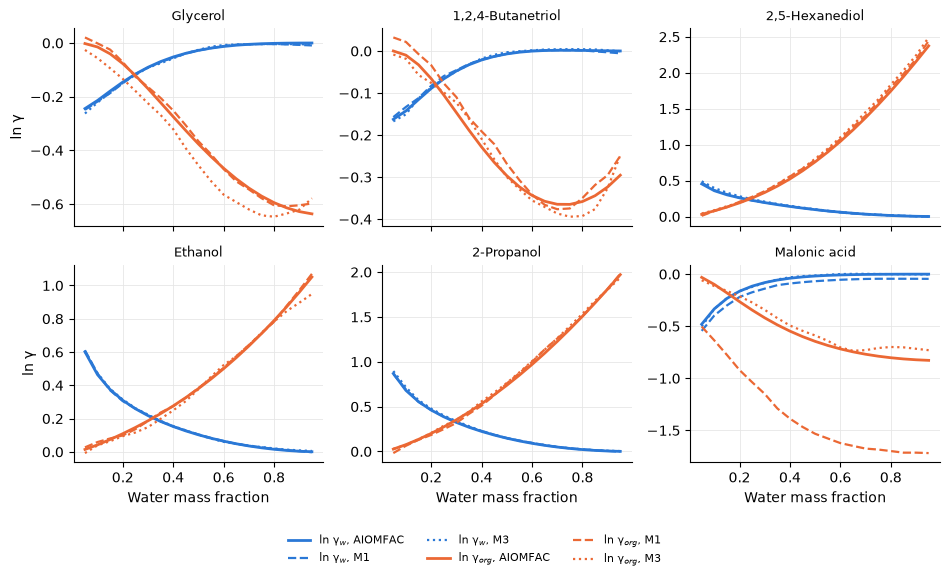

In [5]:
# figure: six compounds, AIOMFAC vs M1 vs M3 (seed mean)
C = ["#2a78d6", "#eb6834"]
fig, axes = plt.subplots(2, 3, figsize=(9.6, 5.6), sharex=True)
for ax, nm in zip(axes.flat, TARGETS):
    for k, (lab, c) in enumerate([("ln γ$_w$", C[0]), ("ln γ$_{org}$", C[1])]):
        ax.plot(W19, truth[nm][:, k], color=c, lw=2, label=f"{lab}, AIOMFAC")
        for mname, ls in [("M1: BIMOG train", "--"), ("M3: all BIMOG + all MCM", ":")]:
            p = np.mean([preds[(mname, s, nm)][:, k] for s in SEEDS], 0)
            ax.plot(W19, p, color=c, lw=1.6, ls=ls, label=f"{lab}, {mname.split(':')[0]}")
    ax.set_title(nm, fontsize=9); ax.grid(color="#e6e6e6", lw=0.6)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
for ax in axes[1]: ax.set_xlabel("Water mass fraction")
for ax in axes[:, 0]: ax.set_ylabel("ln γ")
h, l = axes[0, 0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=3, fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout(rect=(0, 0.06, 1, 1)); plt.savefig("malonic_reeval.png", dpi=300, bbox_inches="tight"); plt.show()